In [18]:
#install pandas
%pip install pandas
#install numpy
%pip install numpy
#install matplotlib
%pip install matplotlib
#install seaborn
%pip install seaborn
#install requests
%pip install requests
#install tqdm
%pip install tqdm
#install geopandas
%pip install geopandas
#install contextily
%pip install contextily


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


...


[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     -------------------------------------- 338.4/338.4 kB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 19.2/19.2 MB 1.5 MB/s eta 0:00:00
     ---------------------------------------- 1.7/1.7 MB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 6.3/6.3 MB 1.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 25.4/25.4 MB 1.3 MB/s eta 0:00:00
     -------------------------------------- 125.4/125.4 kB 1.5 MB/s eta 0:00:00
     ---------------------------------------- 92.7/92.7 kB 1.3 MB/s eta 0:00:00
     -------------------------------------- 308.4/308.4 kB 1.6 MB/s eta 0:00:00
     ---------------------------------------- 40.7/40.7 kB 1.9 MB/s eta 0:00:00
  Using cached attrs-25.4.0-py3-none-any.whl (67 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import geopandas as gpd
from datetime import datetime, timedelta
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO


try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x


In [7]:
# Importar reports diarios de 2020 a 2021 (descarga concurrente, con reintentos)
start = datetime(2020, 1, 1)
end = datetime(2021, 12, 31)
dates = []
d = start
while d <= end:
    dates.append(d)
    d += timedelta(days=1)

base_raw = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_daily_reports/"

# Configurar sesión con reintentos
session = requests.Session()
retries = Retry(total=3, backoff_factor=0.5, status_forcelist=[429,500,502,503,504])
session.mount("https://", HTTPAdapter(max_retries=retries))

def fetch_report(date_obj, session=session, timeout=10):
    url = base_raw + date_obj.strftime("%m-%d-%Y") + ".csv"
    try:
        resp = session.get(url, timeout=timeout)
        if resp.status_code == 200 and resp.text.strip():
            df = pd.read_csv(StringIO(resp.text))
            df['report_date'] = date_obj.date()
            return (date_obj.strftime("%Y-%m-%d"), df, None)
        else:
            return (date_obj.strftime("%Y-%m-%d"), None, f"HTTP {resp.status_code}")
    except Exception as e:
        return (date_obj.strftime("%Y-%m-%d"), None, str(e))

df_list = []
missing = []

# Ajusta workers según tu conexión/CPU; 8 es razonable en local
max_workers = 8
with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(fetch_report, dt): dt for dt in dates}
    for fut in tqdm(as_completed(futures), total=len(futures), desc="Descargando"):
        date_str = None
        try:
            date_str, df_day, err = fut.result()
            if df_day is not None:
                df_list.append(df_day)
            else:
                missing.append((date_str, err))
        except Exception as e:
            # Guardar excepción si algo inesperado sucede en el worker
            missing.append((str(futures[fut].date()), str(e)))

# Concatenar una vez completadas las descargas
if df_list:
    df = pd.concat(df_list, ignore_index=True)
else:
    df = pd.DataFrame()

print(f"Archivos leídos: {len(df_list)}, faltantes: {len(missing)}")
if missing:
    print("Ejemplos de faltantes:", missing[:10])

Descargando: 100%|██████████| 731/731 [01:22<00:00,  8.88it/s]


Archivos leídos: 710, faltantes: 21
Ejemplos de faltantes: [('2020-01-04', 'HTTP 404'), ('2020-01-07', 'HTTP 404'), ('2020-01-03', 'HTTP 404'), ('2020-01-08', 'HTTP 404'), ('2020-01-05', 'HTTP 404'), ('2020-01-01', 'HTTP 404'), ('2020-01-02', 'HTTP 404'), ('2020-01-06', 'HTTP 404'), ('2020-01-09', 'HTTP 404'), ('2020-01-10', 'HTTP 404')]


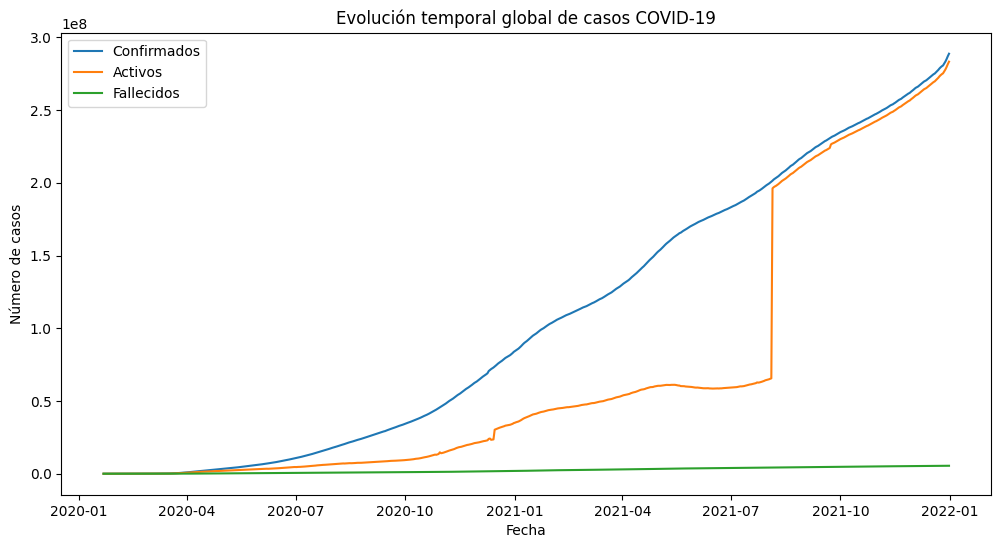

In [8]:
#1. Evolución temporal global de casos confirmados, activos y fallecidos (líneas). 
df['Confirmed'] = pd.to_numeric(df['Confirmed'], errors='coerce').fillna(0)
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce').fillna(0)
df['Recovered'] = pd.to_numeric(df['Recovered'], errors='coerce').fillna(0)
df['Active'] = df['Confirmed'] - df['Deaths'] - df['Recovered']
time_series = df.groupby('report_date').agg({'Confirmed':'sum', 'Active':'sum', 'Deaths':'sum'}).reset_index()
plt.figure(figsize=(12,6))
plt.plot(time_series['report_date'], time_series['Confirmed'], label='Confirmados')
plt.plot(time_series['report_date'], time_series['Active'], label='Activos')
plt.plot(time_series['report_date'], time_series['Deaths'], label='Fallecidos')
plt.xlabel('Fecha')
plt.ylabel('Número de casos')
plt.title('Evolución temporal global de casos COVID-19')
plt.legend()
plt.show()

C:\Users\rodri\AppData\Local\Temp\ipykernel_15292\351097744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_countries, x='Confirmed', y='Country_Region', palette='viridis')


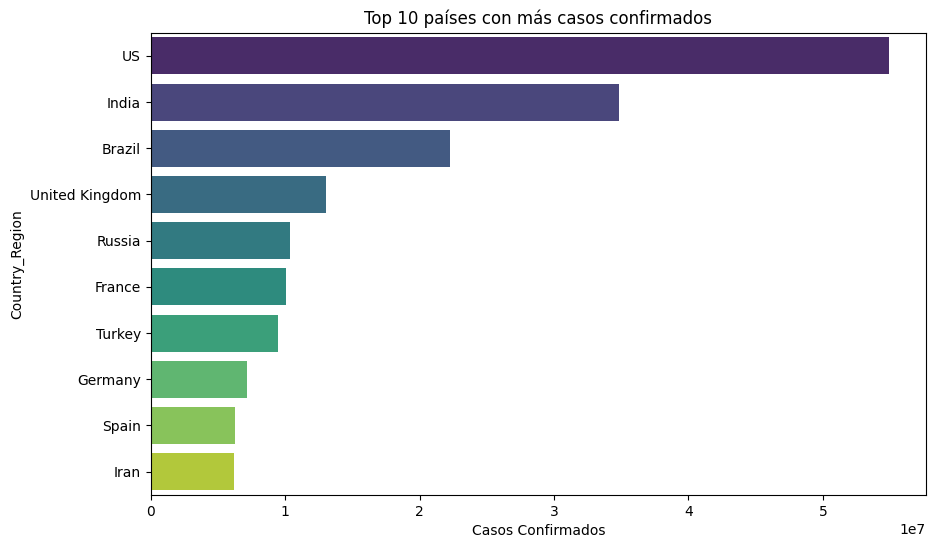

In [9]:

#2. Comparativa Top 10 países con más casos confirmados (barras). 
latest_date = df['report_date'].max()
latest_data = df[df['report_date'] == latest_date] 
top10_countries = latest_data.groupby('Country_Region')['Confirmed'].sum().nlargest(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top10_countries, x='Confirmed', y='Country_Region', palette='viridis')
plt.xlabel('Casos Confirmados')
plt.title('Top 10 países con más casos confirmados')
plt.show()

<Axes: >

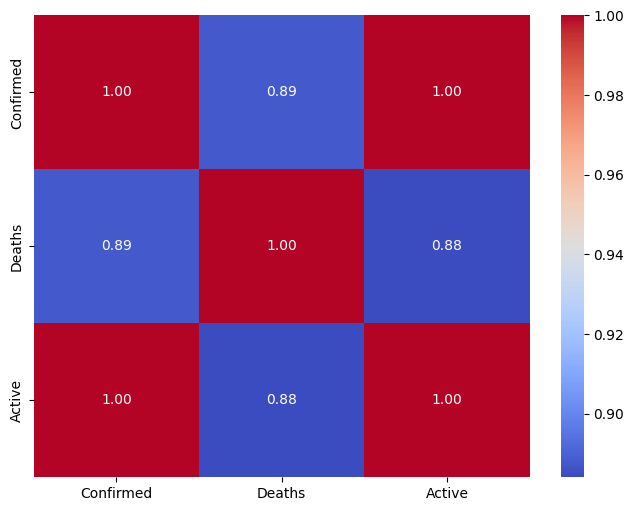

In [10]:
#3. Heatmap de correlaciones entre columnas relevantes (confirmados, fallecidos, activos, ratio). 
corr_data = latest_data[['Confirmed', 'Deaths', 'Active']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")


Diamond Princess not found in regex
MS Zaandam not found in regex
MS Zaandam not found in regex
Summer Olympics 2020 not found in regex
Summer Olympics 2020 not found in regex
Winter Olympics 2022 not found in regex
Winter Olympics 2022 not found in regex
C:\Users\rodri\AppData\Local\Temp\ipykernel_15292\1478289813.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latest_data['Continent'] = cc.convert(names=latest_data.get('Country_Region', '').fillna(''),
C:\Users\rodri\AppData\Local\Temp\ipykernel_15292\1478289813.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

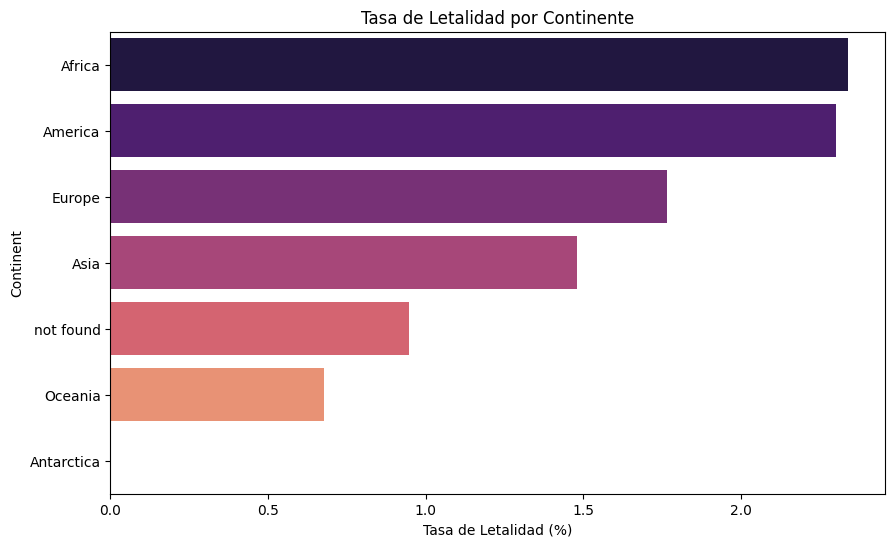

In [13]:
#4. Gráfico de barras horizontales comparando tasas de letalidad por continente.
# Asegurar que exista una columna de continente (insensible a mayúsculas).
continent_col = next((c for c in latest_data.columns if c.lower() == 'continent'), None)

if continent_col is None:
    # Intentar obtener continente desde el nombre del país
    try:
        import country_converter as coco
    except Exception:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "country_converter"])
        import country_converter as coco

    cc = coco.CountryConverter()
    latest_data['Continent'] = cc.convert(names=latest_data.get('Country_Region', '').fillna(''),
                                           to='continent')
    continent_col = 'Continent'
else:
    # normalizar nombre de columna a 'Continent' para consistencia
    if continent_col != 'Continent':
        latest_data['Continent'] = latest_data[continent_col]
        continent_col = 'Continent'

# Asegurar columnas numéricas y agrupar correctamente
latest_data['Deaths'] = pd.to_numeric(latest_data.get('Deaths', 0), errors='coerce').fillna(0)
latest_data['Confirmed'] = pd.to_numeric(latest_data.get('Confirmed', 0), errors='coerce').fillna(0)

letalidad_data = latest_data.groupby('Continent')[['Deaths', 'Confirmed']].sum().reset_index()

# Evitar división por cero
letalidad_data['Letalidad'] = np.where(
    letalidad_data['Confirmed'] > 0,
    (letalidad_data['Deaths'] / letalidad_data['Confirmed']) * 100,
    0.0
)

plt.figure(figsize=(10,6))
sns.barplot(data=letalidad_data.sort_values('Letalidad', ascending=False),
            x='Letalidad', y='Continent', palette='magma')
plt.xlabel('Tasa de Letalidad (%)')
plt.title('Tasa de Letalidad por Continente')
plt.show()

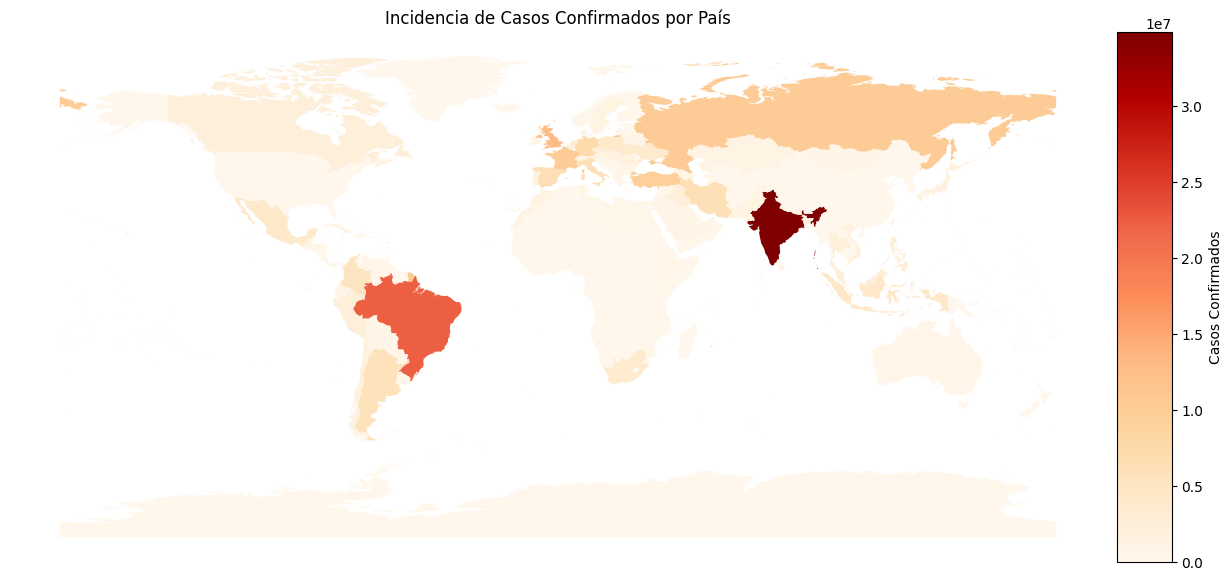

In [22]:
#5. Mapa o gráfico geográfico que muestre la incidencia por continente o país (opcional)
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Intentar cargar naturalearth_lowres (Geopandas < 1.0)
try:
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
except AttributeError:
    # Geopandas >= 1.0: usar GeoJSON público como fallback
    geojson_url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
    world = gpd.read_file(geojson_url)

# Preparar datos de casos por país
country_data = latest_data.groupby('Country_Region', dropna=False)['Confirmed'].sum().reset_index()

# Intentar unir por nombre; si no empata, mostrar aviso y unir por códigos si existen
if 'name' in world.columns:
    merged = world.merge(country_data, how='left', left_on='name', right_on='Country_Region')
else:
    merged = world.merge(country_data, how='left', left_on='ADMIN', right_on='Country_Region')

merged['Confirmed'] = merged['Confirmed'].fillna(0)

# Informar coincidencias aproximadas
matched = merged['Confirmed'].sum() > 0
if not matched:
    print("Aviso: no se encontraron coincidencias entre nombres de países. Revisa 'Country_Region' y 'world' (columnas 'name' o 'ADMIN').")

fig, ax = plt.subplots(1, 1, figsize=(15,10))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)

merged.plot(column='Confirmed', ax=ax, legend=True, cax=cax,
            legend_kwds={'label': "Casos Confirmados",
                         'orientation': "vertical"},
            cmap='OrRd', missing_kwds={"color": "lightgrey"})
ax.set_title('Incidencia de Casos Confirmados por País')
ax.axis('off')
plt.show()